In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch
import time

In [3]:
ROWS, COLS = 6, 7

def initial_state():
    return np.zeros((ROWS, COLS), dtype=int)

# Core Game Function

In [4]:
def PLAYER(board):
    return 1 if np.sum(board == 1) == np.sum(board == -1) else -1

def ACTIONS(board):
    return [c for c in range(COLS) if board[0, c] == 0]

def RESULT(board, col):
    new_board = board.copy()
    player = PLAYER(board)
    for r in range(ROWS - 1, -1, -1):
        if new_board[r, col] == 0:
            new_board[r, col] = player
            break
    return new_board

def _winner(board):
    for p in [1, -1]:
        for r in range(ROWS):
            for c in range(COLS - 3):
                if all(board[r, c:c+4] == p): 
                    return p
        for c in range(COLS):
            for r in range(ROWS - 3):
                if all(board[r:r+4, c] == p): 
                    return p
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                if all(board[r+i, c+i] == p for i in range(4)): 
                    return p
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                if all(board[r-i, c+i] == p for i in range(4)): 
                    return p
    return None

def TERMINAL(board):
    return _winner(board) is not None or len(ACTIONS(board)) == 0

def UTILITY(board):
    w = _winner(board)
    return w if w is not None else 0

# Heuristic evaluation function

In [5]:
def _score_window(window, player):
    """
    Module B: Strategic window scoring
    - Prioritize threats and opportunities
    - Heavy blocking weight
    - Recognize trap patterns
    """
    opp = -player
    p = int(np.sum(window == player))
    o = int(np.sum(window == opp))
    e = int(np.sum(window == 0))
    
    # Winning position
    if p == 4:
        return 100
    
    # Strong threat (3 in a row with 1 empty)
    if p == 3 and e == 1:
        return 5
    
    # Building position (2 in a row with 2 empty)
    if p == 2 and e == 2:
        return 2
    
    # CRITICAL: Must block opponent's 3-in-a-row
    if o == 3 and e == 1:
        return -4
    
    # Recognize opponent building (2 in a row)
    if o == 2 and e == 2:
        return -1
    
    return 0

def heuristic(board):
    """
    Module B: Strategic heuristic evaluation
    Key features:
    1. Center control: Center column is most valuable
    2. Blocking: Prevent opponent threats
    3. Traps: Recognize forced win patterns
    """
    score = 0
    player = 1
    
    # STRATEGIC PRIORITY 1: Center column control
    # Center participates in more winning combinations
    center_array = board[:, COLS // 2]
    center_count = int(np.sum(center_array == player))
    score += center_count * 3
    
    # STRATEGIC PRIORITY 2: Evaluate all windows
    # Horizontal windows
    for r in range(ROWS):
        for c in range(COLS - 3):
            window = board[r, c:c+4]
            score += _score_window(window, player)
    
    # Vertical windows
    for c in range(COLS):
        for r in range(ROWS - 3):
            window = board[r:r+4, c]
            score += _score_window(window, player)
    
    # Diagonal (down-right) windows
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            window = np.array([board[r+i, c+i] for i in range(4)])
            score += _score_window(window, player)
    
    # Diagonal (up-right) windows
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            window = np.array([board[r-i, c+i] for i in range(4)])
            score += _score_window(window, player)
    
    return score

print("Enhanced heuristic with center control and blocking defined")

Enhanced heuristic with center control and blocking defined


# Visualization function

In [6]:
def draw_board(ax, board, title=''):
    ax.clear()
    ax.set_xlim(0, COLS)
    ax.set_ylim(-0.6, ROWS)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0, 0), COLS, ROWS,
                 boxstyle='round,pad=0.05', color='#1d4ed8', zorder=0))
    for r in range(ROWS):
        for c in range(COLS):
            cx, cy = c + 0.5, (ROWS - 1 - r) + 0.5
            color = '#dbeafe'
            if board[r, c] == 1:    color = '#ef4444'
            elif board[r, c] == -1: color = '#fbbf24'
            ax.add_patch(Circle((cx, cy), 0.4, color=color, zorder=1))
    for c in range(COLS):
        ax.text(c + 0.5, -0.35, str(c), ha='center', va='center',
                fontsize=9, color='#6b7280')
    if title:
        ax.set_title(title, fontsize=12, pad=6)

# Minimax with Alpha-Beta Pruning

In [7]:
_COL_ORDER = sorted(range(COLS), key=lambda c: abs(c - COLS // 2))
nodes_visited = 0

def minimax(board, depth, alpha, beta, maximizing, use_pruning=True):
    """
    Module A: Minimax with optional Alpha-Beta Pruning
    
    Alpha: Maximizer's floor (best value Red can guarantee)
    Beta: Minimizer's ceiling (best value Yellow can guarantee)
    
    Pruning logic:
    - If alpha >= beta, current branch cannot improve either player's outcome
    - Safe to skip remaining children (prune the branch)
    """
    global nodes_visited
    nodes_visited += 1

    # Terminal state: return exact utility
    if TERMINAL(board):
        return UTILITY(board) * 1_000_000, None
    
    # Depth limit: use heuristic estimate
    if depth == 0:
        return heuristic(board), None

    # Get valid moves (center-first ordering for better pruning)
    valid_cols = [c for c in _COL_ORDER if c in ACTIONS(board)]

    if maximizing:
        max_eval = -float('inf')
        best_col = valid_cols[0]
        
        for col in valid_cols:
            # Recursive call
            eval_score, _ = minimax(RESULT(board, col), depth - 1, alpha, beta, False, use_pruning)
            
            # Update best evaluation and move
            if eval_score > max_eval:
                max_eval = eval_score
                best_col = col
            
            # MODULE A TASK: Update alpha (Maximizer's floor)
            alpha = max(alpha, eval_score)
            
            # MODULE A TASK: Pruning condition
            # If alpha >= beta, Minimizer won't allow this path
            # No need to explore remaining children
            if use_pruning and alpha >= beta:
                break  # Beta cutoff
            
        return max_eval, best_col

    else:  # Minimizing
        min_eval = float('inf')
        best_col = valid_cols[0]
        
        for col in valid_cols:
            # Recursive call
            eval_score, _ = minimax(RESULT(board, col), depth - 1, alpha, beta, True, use_pruning)
            
            # Update best evaluation and move
            if eval_score < min_eval:
                min_eval = eval_score
                best_col = col
            
            # MODULE A TASK: Update beta (Minimizer's ceiling)
            beta = min(beta, eval_score)
            
            # MODULE A TASK: Pruning condition
            # If alpha >= beta, Maximizer won't allow this path
            # No need to explore remaining children
            if use_pruning and alpha >= beta:
                break  # Alpha cutoff
            
        return min_eval, best_col

print("Minimax with Alpha-Beta Pruning implemented")

Minimax with Alpha-Beta Pruning implemented


# Efficiency Gap Experiment

In [8]:
print("=" * 70)
print("Q1: THE EFFICIENCY GAP - Alpha-Beta vs Standard Minimax")
print("=" * 70)

# Create a test board state (mid-game position)
test_board = initial_state()
test_board = RESULT(test_board, 3)  # Red
test_board = RESULT(test_board, 3)  # Yellow
test_board = RESULT(test_board, 2)  # Red
test_board = RESULT(test_board, 4)  # Yellow
test_board = RESULT(test_board, 3)  # Red

TEST_DEPTH = 5

print(f"\nTest Configuration: Depth = {TEST_DEPTH}")
print(f"Board state after 5 moves:\n")

# Test WITHOUT pruning
print("\n1. STANDARD MINIMAX (No Pruning)")
print("-" * 70)
nodes_visited = 0
start_time = time.time()
eval_no_prune, move_no_prune = minimax(test_board, TEST_DEPTH, -float('inf'), float('inf'), False, use_pruning=False)
time_no_prune = time.time() - start_time
nodes_no_prune = nodes_visited

print(f"   Nodes Visited: {nodes_no_prune:,}")
print(f"   Execution Time: {time_no_prune:.4f} seconds")
print(f"   Best Move: Column {move_no_prune}")
print(f"   Evaluation Score: {eval_no_prune}")

# Test WITH pruning
print("\n2. ALPHA-BETA PRUNING")
print("-" * 70)
nodes_visited = 0
start_time = time.time()
eval_with_prune, move_with_prune = minimax(test_board, TEST_DEPTH, -float('inf'), float('inf'), False, use_pruning=True)
time_with_prune = time.time() - start_time
nodes_with_prune = nodes_visited

print(f"   Nodes Visited: {nodes_with_prune:,}")
print(f"   Execution Time: {time_with_prune:.4f} seconds")
print(f"   Best Move: Column {move_with_prune}")
print(f"   Evaluation Score: {eval_with_prune}")

# Analysis
print("\n3. ANALYSIS")
print("-" * 70)
node_reduction = ((nodes_no_prune - nodes_with_prune) / nodes_no_prune) * 100
time_reduction = ((time_no_prune - time_with_prune) / time_no_prune) * 100

print(f"   Node Reduction: {node_reduction:.2f}%")
print(f"   Time Reduction: {time_reduction:.2f}%")
print(f"   Speedup Factor: {nodes_no_prune / nodes_with_prune:.2f}x")
print(f"   Same Move? {move_no_prune == move_with_prune}")

print("\n   WHY DOES PRUNING WORK?")
print("   " + "-" * 66)
print("   Alpha-Beta pruning eliminates branches that cannot possibly")
print("   affect the final decision. Once we know a move is worse than")
print("   a previously examined alternative, we don't need to fully")
print("   explore it. The pruning is SAFE because:")
print("   - Alpha tracks the minimum score Maximizer is assured")
print("   - Beta tracks the maximum score Minimizer is assured")
print("   - When alpha >= beta, the current node cannot be chosen")
print("   - Center-first ordering explores best moves first, pruning more")
print("=" * 70)

Q1: THE EFFICIENCY GAP - Alpha-Beta vs Standard Minimax

Test Configuration: Depth = 5
Board state after 5 moves:


1. STANDARD MINIMAX (No Pruning)
----------------------------------------------------------------------
   Nodes Visited: 19,156
   Execution Time: 20.1467 seconds
   Best Move: Column 4
   Evaluation Score: 7

2. ALPHA-BETA PRUNING
----------------------------------------------------------------------
   Nodes Visited: 1,461
   Execution Time: 1.2945 seconds
   Best Move: Column 4
   Evaluation Score: 7

3. ANALYSIS
----------------------------------------------------------------------
   Node Reduction: 92.37%
   Time Reduction: 93.57%
   Speedup Factor: 13.11x
   Same Move? True

   WHY DOES PRUNING WORK?
   ------------------------------------------------------------------
   Alpha-Beta pruning eliminates branches that cannot possibly
   affect the final decision. Once we know a move is worse than
   a previously examined alternative, we don't need to fully
   explore

# Depth Performance Analysis

In [9]:
print("\n" + "=" * 70)
print("Q2: DEPTH PERFORMANCE ANALYSIS")
print("=" * 70)

# Create a typical mid-game state
test_board_q2 = initial_state()
for move in [3, 2, 4, 3, 2, 4, 5]:
    test_board_q2 = RESULT(test_board_q2, move)

print("\nTesting AI at different depths (with Alpha-Beta Pruning):\n")

depths_to_test = [4, 5, 6]
results = []

for d in depths_to_test:
    nodes_visited = 0
    start_time = time.time()
    eval_score, best_move = minimax(test_board_q2, d, -float('inf'), float('inf'), False, use_pruning=True)
    elapsed = time.time() - start_time
    
    results.append({
        'depth': d,
        'nodes': nodes_visited,
        'time': elapsed,
        'move': best_move
    })
    
    response_category = "Instant" if elapsed < 0.1 else ("Fast" if elapsed < 0.5 else ("Noticeable" if elapsed < 2.0 else "Slow"))
    
    print(f"Depth {d}:")
    print(f"   Nodes Visited: {nodes_visited:,}")
    print(f"   Time: {elapsed:.4f} seconds")
    print(f"   Best Move: Column {best_move}")
    print(f"   Response: {response_category}")
    print()

print("\nANALYSIS:")
print("-" * 70)
print("Depth Transition Analysis:")
for i, r in enumerate(results):
    if r['time'] < 0.1:
        feel = "instant (<100ms)"
    elif r['time'] < 0.5:
        feel = "fast but perceptible"
    else:
        feel = "noticeable delay"
    print(f"   Depth {r['depth']}: {feel}")

print("\nRECOMMENDATION FOR DEPLOYMENT:")
print("-" * 70)

if results[0]['time'] < 0.5:
    recommended_depth = 5
    reason = "Depth 5 provides good strategic play with fast response"
elif results[0]['time'] < 0.1:
    recommended_depth = 6
    reason = "Hardware can handle depth 6 with acceptable response time"
else:
    recommended_depth = 4
    reason = "Limited processing power requires depth 4 for smooth UX"

print(f"   Recommended Depth: {recommended_depth}")
print(f"   Reason: {reason}")
print(f"\n   Trade-off Analysis:")
print(f"   - Lower depth (3-4): Instant response, tactical play only")
print(f"   - Medium depth (5): Good balance, sees 2-3 moves ahead")
print(f"   - Higher depth (6-7): Strategic play, but noticeable delays")
print(f"\n   For smooth UX without sacrificing intelligence: Depth {recommended_depth}")
print("=" * 70)


Q2: DEPTH PERFORMANCE ANALYSIS

Testing AI at different depths (with Alpha-Beta Pruning):

Depth 4:
   Nodes Visited: 2,155
   Time: 2.2286 seconds
   Best Move: Column 6
   Response: Slow

Depth 5:
   Nodes Visited: 5,332
   Time: 3.9301 seconds
   Best Move: Column 6
   Response: Slow

Depth 6:
   Nodes Visited: 63,779
   Time: 55.2454 seconds
   Best Move: Column 6
   Response: Slow


ANALYSIS:
----------------------------------------------------------------------
Depth Transition Analysis:
   Depth 4: noticeable delay
   Depth 5: noticeable delay
   Depth 6: noticeable delay

RECOMMENDATION FOR DEPLOYMENT:
----------------------------------------------------------------------
   Recommended Depth: 4
   Reason: Limited processing power requires depth 4 for smooth UX

   Trade-off Analysis:
   - Lower depth (3-4): Instant response, tactical play only
   - Medium depth (5): Good balance, sees 2-3 moves ahead
   - Higher depth (6-7): Strategic play, but noticeable delays

   For smoot

# Human vs AI Game

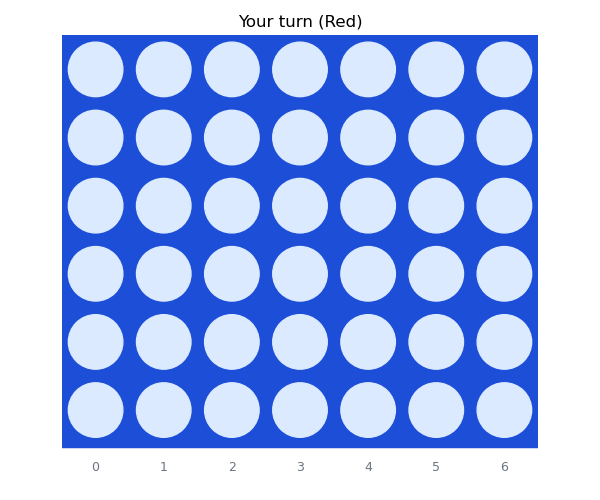


Human vs AI Connect Four
You: Red (Player 1)
AI: Yellow (Player -1) with Alpha-Beta Pruning
AI Depth: 5
Click a column to play


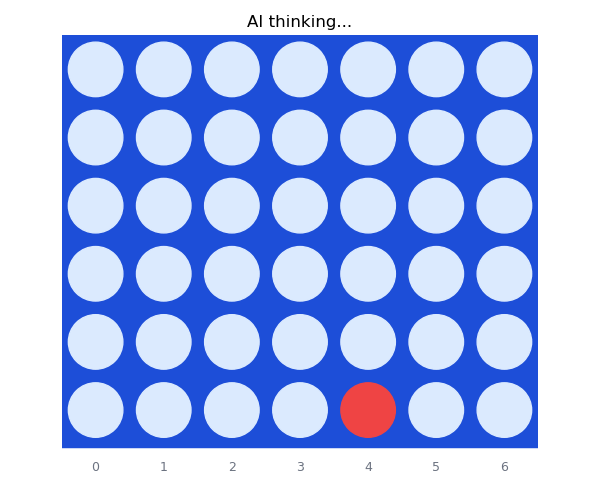

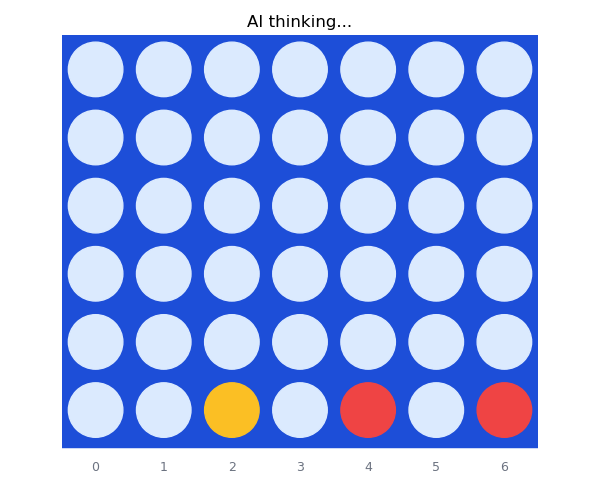

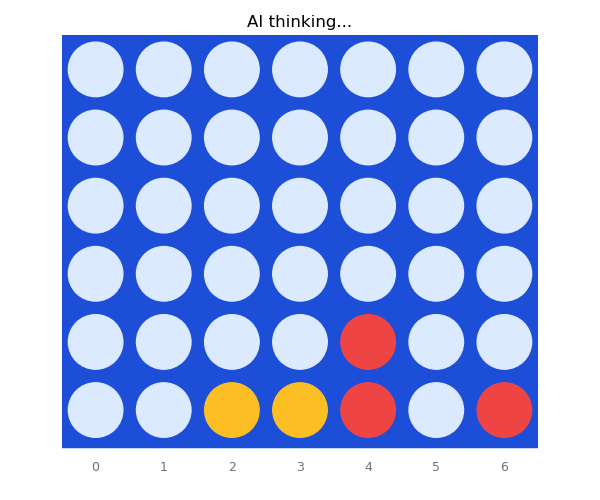

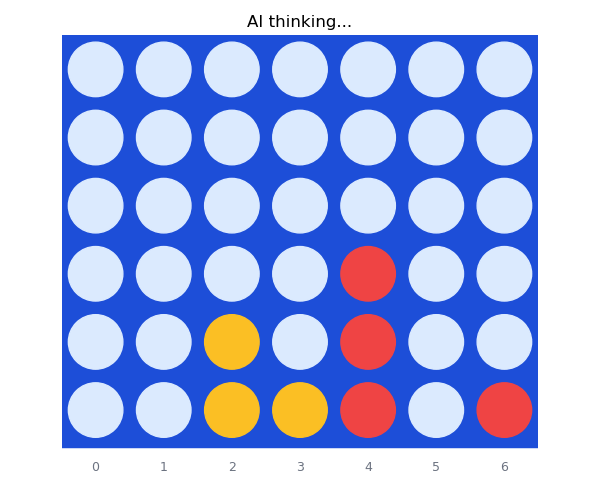

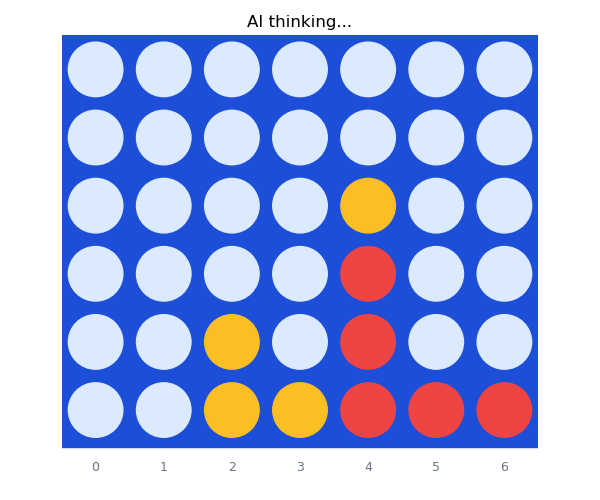

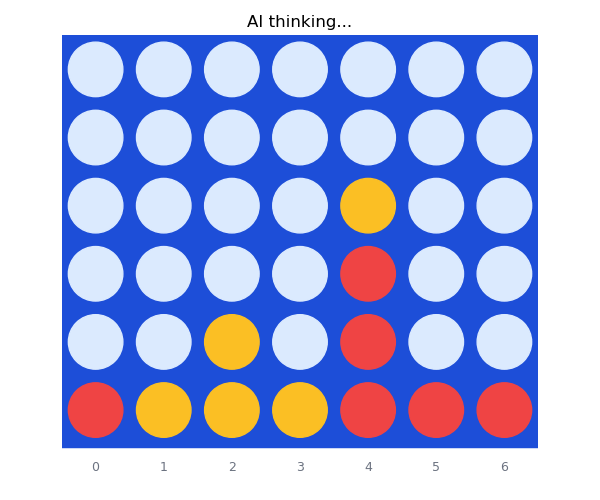

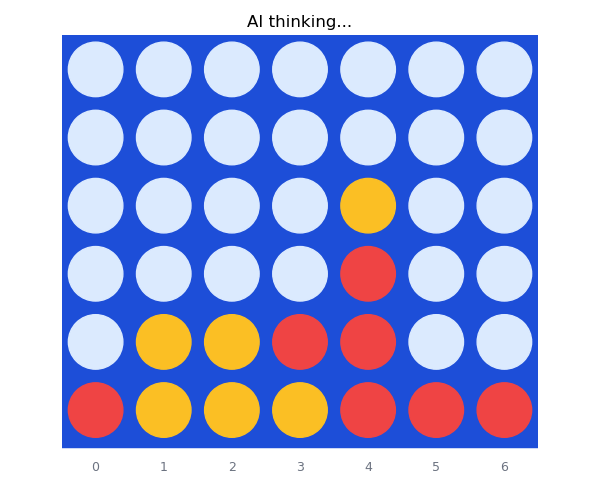

In [10]:
AI_DEPTH = 5
HUMAN_PLAYER = 1
AI_PLAYER = -1

board_ai = initial_state()
fig_ai, ax_ai = plt.subplots(figsize=(6, 5))
fig_ai.canvas.header_visible = False
draw_board(ax_ai, board_ai, "Your turn (Red)")

def _status_ai():
    if not TERMINAL(board_ai):
        current = PLAYER(board_ai)
        return "Your turn (Red)" if current == HUMAN_PLAYER else "AI thinking..."
    u = UTILITY(board_ai)
    return 'You win!' if u == 1 else ('AI wins!' if u == -1 else 'Draw!')

def ai_move():
    global board_ai, nodes_visited
    
    nodes_visited = 0
    start = time.time()
    
    _, best_col = minimax(board_ai, AI_DEPTH, -float('inf'), float('inf'), False, use_pruning=True)
    
    elapsed = time.time() - start
    
    board_ai = RESULT(board_ai, best_col)
    
    status = _status_ai()
    if not TERMINAL(board_ai):
        status = f"Your turn | AI col {best_col} ({nodes_visited:,} nodes, {elapsed:.2f}s)"
    
    draw_board(ax_ai, board_ai, status)
    fig_ai.canvas.draw()

def onclick_ai(event):
    global board_ai
    
    if event.inaxes != ax_ai or TERMINAL(board_ai): 
        return
    
    if PLAYER(board_ai) != HUMAN_PLAYER:
        return
    
    x = event.xdata
    if x is None or not (0 <= x < COLS): 
        return
    
    col = int(x)
    if col not in ACTIONS(board_ai): 
        return
    
    board_ai = RESULT(board_ai, col)
    draw_board(ax_ai, board_ai, _status_ai())
    fig_ai.canvas.draw()
    
    if TERMINAL(board_ai):
        draw_board(ax_ai, board_ai, _status_ai())
        fig_ai.canvas.draw()
        return
    
    fig_ai.canvas.flush_events()
    plt.pause(0.3)
    ai_move()

fig_ai.canvas.mpl_connect('button_press_event', onclick_ai)
plt.tight_layout()
plt.show()

print("\nHuman vs AI Connect Four")
print(f"You: Red (Player 1)")
print(f"AI: Yellow (Player -1) with Alpha-Beta Pruning")
print(f"AI Depth: {AI_DEPTH}")
print("Click a column to play")

# Reset Game

In [11]:
board_ai = initial_state()
draw_board(ax_ai, board_ai, "Your turn (Red)")
fig_ai.canvas.draw()
print("Game reset")

Game reset
